# 03 · Real data pipeline: wiring, signal propagation, noise ceiling, and the peptide test

This notebook turns the public *C. elegans* data into the `Dataset` format that every ladder notebook consumes. Along the way it computes the descriptive quantities that E1 depends on.

**Sources.** All are bundled in the Leifer lab's `wormneuroatlas` package (cite the original papers; see the package's `SEE_README_FOR_CITATIONS`).

| Data | Paper | Role in the project |
|---|---|---|
| Signal-propagation atlas (per-trial ΔF/F responses to single-neuron optogenetic stimulation) | Randi et al. 2023 | interventional targets for E1; noise ceiling |
| Same atlas in **unc-31** mutants (no dense-core-vesicle / neuropeptide release) | Randi et al. 2023 | a second intervention that deletes the L3 channel |
| Chemical + electrical connectome | White et al. 1986; Witvliet et al. 2021 (as compiled) | wiring for L0–L4 |
| Predicted synapse signs | CeNGEN-based (Fenyves et al. 2020 approach) | signs for L0; initialization for L1+ |
| Peptidergic connectome | Ripoll-Sánchez et al. 2023 | extrasynaptic channel for L3 |

**Conventions.** Matrices are indexed `[post, pre]`. `mean[strain, i, s]` is the response of neuron *i* when neuron `stim[s]` is stimulated.

In [1]:
#@title Setup — run first (works locally on a Mac/PC and on Colab)
import os, sys, subprocess
REPO_URL   = "https://github.com/aslansd/Closure-Bench.git"  # Colab only: clone from here
DRIVE_PATH = "/content/drive/MyDrive/Closure-Bench"          # Colab only: ...or use a Drive copy
IN_COLAB = "google.colab" in sys.modules

def _find_package():
    # 1) explicit location, 2) the repo this notebook lives in, 3) Colab clone / Drive
    cands = [os.environ.get("CLOSUREBENCH_ROOT", ""), ".", "..", "/content/Closure-Bench", DRIVE_PATH]
    for root in cands:
        if root and os.path.isdir(os.path.join(root, "closurebench")):
            return os.path.abspath(root)
    if IN_COLAB:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "wormneuroatlas", "optax"], check=False)
        if subprocess.run(["git", "clone", "-q", REPO_URL, "/content/Closure-Bench"]).returncode == 0:
            return "/content/Closure-Bench"
        from google.colab import drive
        drive.mount("/content/drive")
        if os.path.isdir(os.path.join(DRIVE_PATH, "closurebench")):
            return DRIVE_PATH
    raise RuntimeError("closurebench not found. Locally: open this notebook from Closure-Bench/notebooks/, "
                       "or set the environment variable CLOSUREBENCH_ROOT to the Closure-Bench folder.")

ROOT = _find_package()
sys.path.insert(0, ROOT)
try:
    import jax, optax, wormneuroatlas  # noqa: F401
except ImportError as e:
    raise ImportError(f"{e}. Locally, create the environment first: see README.md "
                      "('Run locally'), then select the 'Python (closurebench)' kernel.") from None
RESULTS = os.environ.get("CLOSUREBENCH_RESULTS", os.path.join(ROOT, "results"))
os.makedirs(RESULTS, exist_ok=True)
from closurebench import config as CBC
MODE = CBC.get_mode()        # 'smoke' | 'laptop' | 'full'  (env CLOSUREBENCH_MODE, default: full on GPU, laptop on CPU)
print("closurebench:", ROOT); print("results:", RESULTS); print(CBC.describe_machine()); print("MODE:", MODE)

closurebench: /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac
results: /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac/results
Darwin arm64 | python 3.11.5 | jax 0.10.2 on cpu (cpu) | CPU cores: 8
MODE: laptop


In [2]:
import numpy as np, matplotlib.pyplot as plt
from closurebench import data as D
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
atlas = D.open_atlas()          # offline-safe: skips the WormBase version check
ds = D.load_atlas_dataset(strains=("wt", "unc31"), atlas=atlas)
print(ds.summary())
ds.save(os.path.join(RESULTS, "atlas_dataset.npz"))
print("saved ->", os.path.join(RESULTS, "atlas_dataset.npz"))

*This version of the NeuroAtlas does not include the CAN neurons. This will be fixed soon.
Dataset: N=300 neurons, S=173 stimulated neurons, strains=('wt', 'unc31')
  chemical synapses: 4051  gap-junction pairs: 825  peptidergic pairs: 58112
  signs: +732 / -669 / unknown 2650 (on existing synapses)
  wt: 23901 observed pairs, median trials 3
  unc31: 8876 observed pairs, median trials 1
saved -> /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac/results/atlas_dataset.npz


## 1 · What the data look like

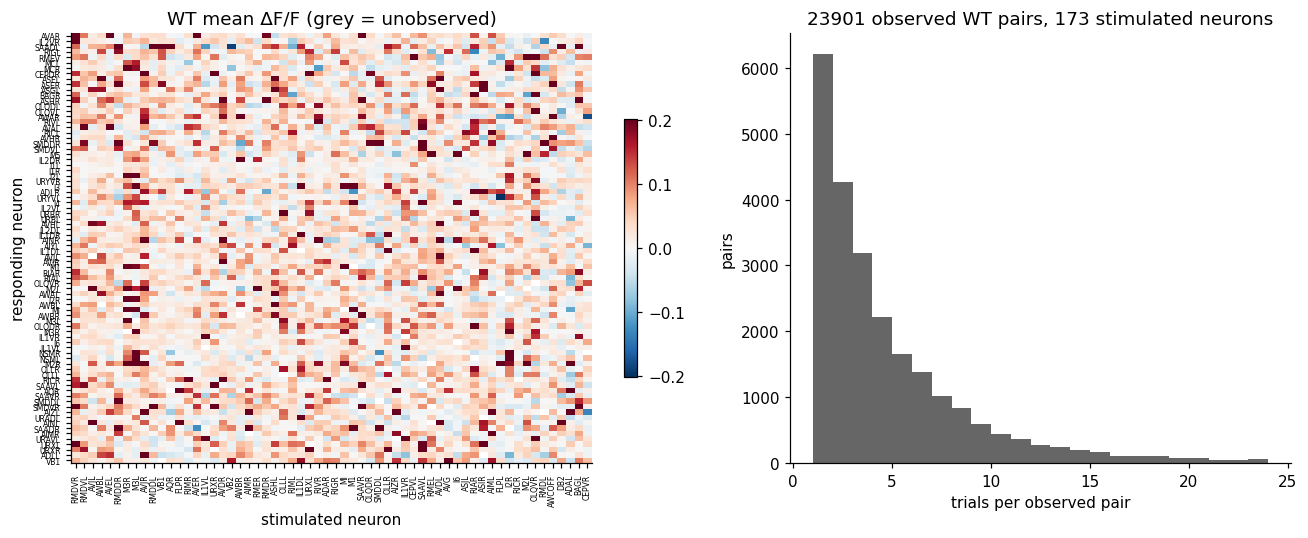

In [3]:
m = ds.mask()[0]
order = np.argsort(-ds.n[0].sum(0))[:60]          # 60 most-sampled stimulated neurons
rows = np.argsort(-m[:, order].sum(1))[:80]
img = np.where(m[np.ix_(rows, order)], ds.mean[0][np.ix_(rows, order)], np.nan)
fig, ax = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={"width_ratios": [1.3, 1]})
v = np.nanpercentile(np.abs(img), 97)
im = ax[0].imshow(img, cmap="RdBu_r", vmin=-v, vmax=v, aspect="auto", interpolation="nearest")
ax[0].set_xticks(range(len(order))); ax[0].set_xticklabels(ds.ids[ds.stim[order]], rotation=90, fontsize=5)
ax[0].set_yticks(range(len(rows))); ax[0].set_yticklabels(ds.ids[rows], fontsize=5)
ax[0].set_xlabel("stimulated neuron"); ax[0].set_ylabel("responding neuron"); ax[0].set_title("WT mean ΔF/F (grey = unobserved)")
plt.colorbar(im, ax=ax[0], shrink=0.6)
ax[1].hist(ds.n[0][m], bins=np.arange(1, 25), color="0.4"); ax[1].set_xlabel("trials per observed pair"); ax[1].set_ylabel("pairs")
ax[1].set_title(f"{m.sum()} observed WT pairs, {ds.S} stimulated neurons")
plt.tight_layout(); plt.show()

## 2 · How much does wiring explain? (motivates the ladder)

Randi et al. reported that functional propagation often departs from anatomical wiring. We reproduce the simplest version of that observation: among pairs with a significant response (atlas q-value < 0.05), what fraction have a direct chemical or electrical contact, and how does that compare with non-significant pairs?

significant pairs: 1150  (4.8% of tested pairs)
  with a direct anatomical contact: 29.0%
non-significant pairs with a direct contact: 13.2%


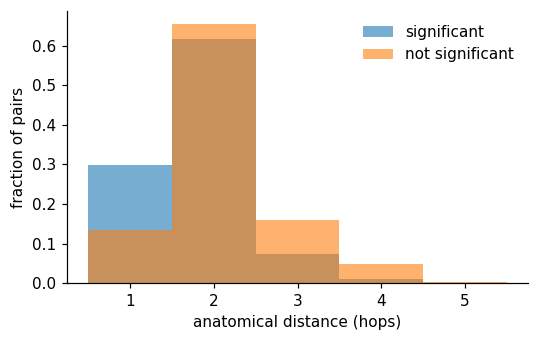

In [4]:
q = atlas.get_signal_propagation_q("wt")[:, ds.stim]
direct = ((ds.chem > 0) | (ds.gap > 0) | (ds.chem.T > 0))[:, ds.stim]
valid = m & np.isfinite(q)
sig_ = valid & (q < 0.05); nonsig = valid & (q >= 0.05)
print(f"significant pairs: {sig_.sum()}  ({sig_.sum() / valid.sum():.1%} of tested pairs)")
print(f"  with a direct anatomical contact: {direct[sig_].mean():.1%}")
print(f"non-significant pairs with a direct contact: {direct[nonsig].mean():.1%}")
# distance in hops on the undirected chemical+gap graph
import scipy.sparse.csgraph as csg
A = ((ds.chem > 0) | (ds.gap > 0)).astype(float); A = np.maximum(A, A.T)
hops = csg.shortest_path(A, unweighted=True)[:, ds.stim]
fig, ax = plt.subplots(figsize=(5, 3.2))
for lab, sel in [("significant", sig_), ("not significant", nonsig)]:
    h = hops[sel]; h = h[np.isfinite(h)]
    ax.hist(h, bins=np.arange(0.5, 6.5), density=True, alpha=0.6, label=lab)
ax.set_xlabel("anatomical distance (hops)"); ax.set_ylabel("fraction of pairs"); ax.legend(frameon=False)
plt.tight_layout(); plt.show()

## 3 · Noise ceiling

The loader rejects trials with ΔF/F < −1. Fluorescence cannot be negative, so such values are artifacts. Only 11 of ~107k trials are affected, but one of them (ΔF/F ≈ −105) alone inflated the mean noise variance about eightfold.

E1 scores every model relative to the noise ceiling, the accuracy the best possible model could reach given trial-to-trial variability (across animals and trials).

`metrics.feve` builds the ceiling into its definition by subtracting the variance of each trial mean. Here we check that the trial data support this: for pairs with ≥4 trials, split the trials in half and correlate the two half-means across pairs. The Spearman–Brown correction gives the reliability of the full mean.

Expect low reliability across *all* pairs, because most pairs do not respond at all (true signal ≈ 0). Reliability among significant pairs is the meaningful number. Pooled FEVE is dominated by null pairs, which is why Notebook 04 also reports FEVE restricted to significant pairs.

In [5]:
allt = atlas.get_signal_propagation_map_all("wt")[:, ds.stim]
rng = np.random.default_rng(0)
def split_half(min_trials=4, n_rep=50):
    rs = []
    idx = [ix for ix in zip(*np.nonzero((ds.n[0] >= min_trials) & m))]
    for _ in range(n_rep):
        a, b = [], []
        for i, s in idx:
            t = np.asarray(allt[i, s], float); t = t[np.isfinite(t) & (t >= -1)]; rng.shuffle(t)
            h = len(t) // 2; a.append(t[:h].mean()); b.append(t[h:2 * h].mean())
        r = np.corrcoef(a, b)[0, 1]; rs.append(2 * r / (1 + r))
    return np.mean(rs), np.percentile(rs, [2.5, 97.5]), len(idx)
rel, ci, npairs = split_half()
print(f"split-half reliability (Spearman-Brown), all {npairs} pairs with >=4 trials: {rel:.3f}  [{ci[0]:.3f}, {ci[1]:.3f}]")
_m_backup = m
m = _m_backup & np.nan_to_num(q < 0.05)          # significant pairs only
rel_s, ci_s, np_s = split_half()
m = _m_backup
print(f"                                   significant pairs only ({np_s}): {rel_s:.3f}  [{ci_s[0]:.3f}, {ci_s[1]:.3f}]")
v1 = (ds.var_mean[0] * ds.n[0])[ds.n[0] >= 2]
print(f"single-trial noise SD: median {np.sqrt(np.median(v1)):.3f}, RMS {np.sqrt(v1.mean()):.3f} (heavy-tailed)   SD of WT trial means: {ds.mean[0][m].std():.3f}")

split-half reliability (Spearman-Brown), all 10213 pairs with >=4 trials: 0.416  [0.402, 0.437]
                                   significant pairs only (728): 0.596  [0.534, 0.646]
single-trial noise SD: median 0.066, RMS 0.124 (heavy-tailed)   SD of WT trial means: 0.092


## 4 · The unc-31 test: how big is the peptidergic contribution?

unc-31 animals lack neuropeptide release, so for pairs measured in both strains, $\Delta = \text{WT} - \text{unc-31}$ contains the peptidergic contribution plus noise. The noise part is known from trial variability, so the **excess variance** of Δ over noise estimates the peptide signal.

This is an L0–L2 vs L3 question asked directly of the data. Rungs without a peptide channel predict zero excess. We bootstrap over stimulated neurons.

*Caveat:* unc-31 also affects other dense-core-vesicle cargo (e.g. monoamines co-packaged in DCVs) and may have developmental effects, so this is an upper-bound-style estimate of the peptidergic component.

In [6]:
def excess(cols, both):
    sel = both[:, cols]
    dlt = (ds.mean[0] - ds.mean[1])[:, cols][sel]
    nv = (ds.var_mean[0] + ds.var_mean[1])[:, cols][sel]
    wt = ds.mean[0][:, cols][sel]
    return (dlt ** 2).mean() - nv.mean(), (wt ** 2).mean() - ds.var_mean[0][:, cols][sel].mean()

for min_n, label in [(2, "primary: >=2 trials in both strains (each pair's own noise estimate)"),
                     (1, "sensitivity: >=1 trial (single-trial pairs use pooled noise)")]:
    both = (ds.n[0] >= min_n) & (ds.n[1] >= min_n) & m
    cols_all = np.nonzero(both.any(0))[0]
    ex, sig_wt = excess(cols_all, both)
    boots = np.array([excess(rng.choice(cols_all, len(cols_all)), both) for _ in range(2000)])
    ratio = np.sqrt(np.clip(boots[:, 0], 0, None) / np.clip(boots[:, 1], 1e-12, None))
    print(label)
    print(f"  pairs: {both.sum()} across {len(cols_all)} stimulated neurons")
    print(f"  excess variance of WT-unc31 over noise: {ex:.5f}  95% CI [{np.percentile(boots[:,0],2.5):.5f}, {np.percentile(boots[:,0],97.5):.5f}]")
    print(f"  peptide-signal SD / WT-signal SD: {np.sqrt(max(ex,0) / sig_wt):.2f}  95% CI [{np.percentile(ratio,2.5):.2f}, {np.percentile(ratio,97.5):.2f}]")
both = (ds.n[0] >= 2) & (ds.n[1] >= 2) & m   # used below

primary: >=2 trials in both strains (each pair's own noise estimate)
  pairs: 3366 across 70 stimulated neurons
  excess variance of WT-unc31 over noise: 0.00115  95% CI [-0.00024, 0.00281]
  peptide-signal SD / WT-signal SD: 0.62  95% CI [0.00, 0.99]
sensitivity: >=1 trial (single-trial pairs use pooled noise)
  pairs: 8149 across 105 stimulated neurons
  excess variance of WT-unc31 over noise: 0.00057  95% CI [-0.00174, 0.00316]
  peptide-signal SD / WT-signal SD: 0.43  95% CI [0.00, 0.97]


The two estimates differ, which shows how strongly this number depends on the noise model. Treat the primary (≥2 trials) estimate as the headline figure, and quote the range. Notebook 02 calibrates synthetic worms against it (`peptide_scale`).

**Where is the peptidergic excess?** The organismic prediction in E1 is that residual error beyond wired rungs concentrates in neurons dominated by extrasynaptic signalling. As an exploratory preview (not a registered test), we correlate each responder's excess WT–unc-31 variance with its peptidergic in-degree.

In [7]:
from scipy.stats import spearmanr
dlt2 = np.where(both, (ds.mean[0] - ds.mean[1]) ** 2 - (ds.var_mean[0] + ds.var_mean[1]), np.nan)
nb = both.sum(1)
resp_ex = np.where(nb >= 5, np.nanmean(dlt2, 1), np.nan)
pep_in = (ds.pep > 0).sum(1)
syn_in = (ds.chem > 0).sum(1) + (ds.gap > 0).sum(1)
ok = np.isfinite(resp_ex)
for name, x in [("peptidergic in-degree", pep_in), ("synaptic in-degree", syn_in)]:
    r, p = spearmanr(x[ok], resp_ex[ok]); print(f"{name:22s} vs per-neuron excess: rho={r:+.2f}  p={p:.3g}  (n={ok.sum()} neurons)")

peptidergic in-degree  vs per-neuron excess: rho=+0.16  p=0.0688  (n=132 neurons)
synaptic in-degree     vs per-neuron excess: rho=+0.17  p=0.0459  (n=132 neurons)


## 5 · Outputs

* `results/atlas_dataset.npz`: the full `Dataset` (300 neurons, wiring, WT and unc-31 responses). Notebooks 04+ load it with `D.Dataset.load(...)`.
* Numbers for the proposal or first paper (`laptop` run of 2026-10-04):
  * 1,150 significant pairs (4.8% of tested pairs); 29.0% of them have a direct contact, vs 13.2% of non-significant pairs.
  * Split-half reliability: 0.42 over all pairs, 0.60 over significant pairs.
  * Peptide-signal SD / WT-signal SD: 0.62, 95% CI [0.00, 0.99]; the sensitivity analysis gives 0.43 [0.00, 0.97].
  * Per-neuron WT − unc-31 excess vs peptidergic in-degree: ρ = 0.16, p = 0.07.

  In general: significant-pair fraction, the share without direct contact, split-half reliability, and the peptidergic SD ratio with CI.

**Before E1 on real data (Notebook 04):** run Notebook 02 on synthetic worms with this exact wiring and coverage, to confirm the pipeline recovers a known closed level under these noise levels.

**Data to add later:** spontaneous whole-brain activity with behaviour (Atanas et al. 2023) for the E1 fit-on-spontaneous condition; developmental connectomes (Witvliet et al. 2021, stages L1→adult) for E3-style checks; full time courses (kernels) instead of window amplitudes. The atlas stores fitted kernels, but `NeuroAtlas.get_kernel` has a bug in v0.0.7.3 (`len(exp>0)`), so read `funatlas_h5[strain]["kernels"]` directly.